# SECTION 1 — Environment Setup

# Load Prediction Classification Experiment

This notebook evaluates the performance of:

- Single classifiers
- CombinedClassifier aggregation

on the Load Prediction dataset.

Metrics:
- Accuracy
- F1-score
- Precision
- Recall

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


# SECTION 2 — Dataset Loading

In [2]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("ninzaami/loan-predication")
os.listdir(path)


['train_u6lujuX_CVtuZ9i (1).csv']

In [3]:
df = pd.read_csv(os.path.join(path, "train_u6lujuX_CVtuZ9i (1).csv"))
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# SECTION 3 — Exploratory Data Analysis

In [4]:
print(df.shape)
df.info()

(614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

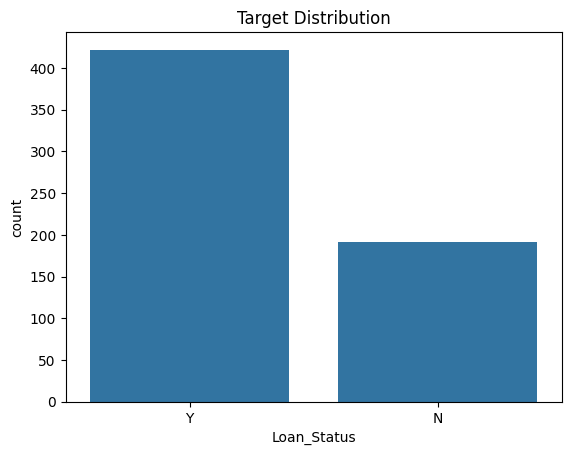

In [6]:
sns.countplot(x=df["Loan_Status"])

plt.title("Target Distribution")
plt.show()

# SECTION 4 — Data Preprocessing

In [7]:
target = "Loan_Status"
df[target] = df[target].astype(str).str.strip()
df[target] = df[target].map({"Y": 1, "N": 0})

In [8]:
target = "Loan_Status"

X = df.drop(columns=["Loan_ID", target])
y = df[target]

In [9]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols, num_cols

(['Gender',
  'Married',
  'Dependents',
  'Education',
  'Self_Employed',
  'Property_Area'],
 ['ApplicantIncome',
  'CoapplicantIncome',
  'LoanAmount',
  'Loan_Amount_Term',
  'Credit_History'])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# SECTION 5 — Train Models

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "random_forest_classifier": RandomForestClassifier(n_estimators=300, random_state=42),
    "svc": SVC(probability=True),
    "k_neighbors_classifier": KNeighborsClassifier(),
    "gaussian_nb": GaussianNB(),
}

def evaluate_classification(y_true, y_pred):
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall"   : recall_score(y_true, y_pred, average='weighted'),
        "F1 Score" : f1_score(y_true, y_pred, average='weighted'),
    }
    return metrics

In [13]:
from cobra.combine_classifier import CombineClassifier

results = {}

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

combined_classifier = CombineClassifier(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
combined_classifier.fit(X_train_p, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred_combine = combined_classifier.predict(X_test_p)
predict_time = time.perf_counter() - start_pred

metrics_combine = evaluate_classification(y_test, y_pred_combine)
results["combine_classifier"] = metrics_combine
print(f"Results for combine_classifier: {metrics_combine}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [00:00<00:00, 414.91it/s]

Results for combine_classifier: {'Accuracy': 0.8536585365853658, 'Precision': 0.8625687772029235, 'Recall': 0.8536585365853658, 'F1 Score': 0.8427034515786953}

Time computing : fit 1.056160332998843, predict 0.006678333011223003


In [14]:
combined_classifier.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 9.097080267558528,
 'score': np.float64(0.20342857142857143),
 'history':      iter     score      risk  bandwidth
 0       0  0.341306  0.341306   0.001000
 1       1  0.341306  0.341306   0.034441
 2       2  0.341306  0.341306   0.067883
 3       3  0.341306  0.341306   0.101324
 4       4  0.341306  0.341306   0.134766
 ..    ...       ...       ...        ...
 295   295  0.203429  0.203429   9.866234
 296   296  0.203429  0.203429   9.899676
 297   297  0.203429  0.203429   9.933117
 298   298  0.203429  0.203429   9.966559
 299   299  0.203429  0.203429  10.000000
 
 [300 rows x 4 columns]}

In [15]:
for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    metrics = evaluate_classification(y_test, y_pred)
    results[name] = metrics

In [16]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score
k_neighbors_classifier,0.869919,0.882422,0.869919,0.860181
logistic_regression,0.861789,0.875999,0.861789,0.850399
combine_classifier,0.853659,0.862569,0.853659,0.842703
svc,0.853659,0.869641,0.853659,0.840441
gaussian_nb,0.845528,0.850101,0.845528,0.835078
random_forest_classifier,0.821138,0.816452,0.821138,0.814636


<Axes: xlabel='bandwidth', ylabel='score'>

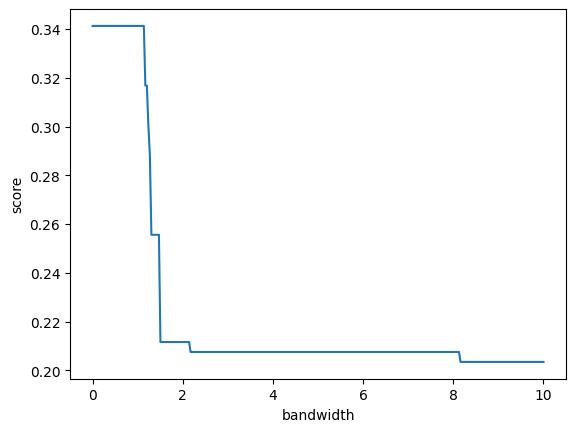

In [17]:
df_output = combined_classifier.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

# SECTION 6 — External training

In [18]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train_p,
    y_train,
    test_size=0.5,
    random_state=42,
    stratify=y_train
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test_p)
    for m in fit_models.values()
])

combined = CombineClassifier(
    estimators=fit_models.keys(),
    random_state=42,
)

combined.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = combined.predict(
    X=P_test
)

metrics_combine = evaluate_classification(y_test, y_pred)
metrics_combine


search: 100%|██████████| 300/300 [00:00<00:00, 403.29it/s]


{'Accuracy': 0.8617886178861789,
 'Precision': 0.8759985860728171,
 'Recall': 0.8617886178861789,
 'F1 Score': 0.850398579307016}

In [19]:
from sklearn.preprocessing import MinMaxScaler
from cobra.combine_classifier import CombineClassifier
from kfc_procedure.kfc import KFCClassifier
models = {
    "logistic_regression": LogisticRegression(),
    "random_forest_classifier": RandomForestClassifier(),
    "svc": SVC(probability=True),
    "k_neighbors_classifier": KNeighborsClassifier(),
    "gaussian_nb": GaussianNB(),
}
scaler = MinMaxScaler(feature_range=(0.05, 0.95))
seeds = [0, 42, 100, 2024, 999]
results = []

In [25]:
X_trans = preprocessor.fit_transform(X)
for seed in seeds:
    print(f"Running seed = {seed}")
    X_train, X_test, y_train, y_test = train_test_split(
        X_trans,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed,
    )

    print("Running base models...")
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = evaluate_classification(y_test, y_pred)
        response = {
            "model": name,
            "seed": seed,
            **metrics
        }
        results.append(response)
    
    # implement combine classifier
    print("Running combined classifier...")
    combined = CombineClassifier(
        estimators=models.keys(),
        random_state=seed,
    )

    combined.fit(X_train, y_train)
    y_pred = combined.predict(X_test)
    metrics = evaluate_classification(y_test, y_pred)
    response = {
        "model" : "combined classifier",
        "seed" : seed,
        **metrics
    }
    results.append(response)

    # implement kfc
    # scale value to positive
    print("Running KFC classifier...")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    kfc = KFCClassifier(
        divergences=['euclidean', 'gkl', 'is', "logistic"],
        local_model="logistic_regression",
        combiner="combiner_classifier",
        n_clusters=2,
        random_state=seed
    )

    kfc.fit(X_train_scaled, y_train)
    y_pred = kfc.predict(X_test_scaled)
    metrics = evaluate_classification(y_test, y_pred)
    response = {
        "model" : "kfc",
        "seed" : seed,
        **metrics
    }
    results.append(response)
    

Running seed = 0
Running base models...
Running combined classifier...


search: 100%|██████████| 300/300 [00:00<00:00, 414.26it/s]


Running KFC classifier...
P_l : (246, 4), y_l : (246,)


search: 100%|██████████| 300/300 [00:00<00:00, 411.81it/s]


Running seed = 42
Running base models...
Running combined classifier...


...

search: 100%|██████████| 300/300 [00:00<00:00, 409.65it/s]


Running seed = 999
Running base models...
Running combined classifier...


search: 100%|██████████| 300/300 [00:00<00:00, 406.67it/s]


Running KFC classifier...
P_l : (246, 4), y_l : (246,)


search: 100%|██████████| 300/300 [00:00<00:00, 404.30it/s]


In [27]:
summary = (
    pd.DataFrame(results)
    .groupby("model")[["Accuracy", "Precision", "Recall", "F1 Score"]]
    .agg(["mean", "std"])
    .sort_values(("Accuracy", "mean"), ascending=False)
)
summary

Accuracy           Precision              Recall  \
                              mean       std      mean       std      mean   
model                                                                        
logistic_regression       0.834271  0.018039  0.853251  0.015477  0.834271   
combined classifier       0.828643  0.021372  0.848178  0.022752  0.828643   
svc                       0.826767  0.016390  0.847869  0.017270  0.826767   
k_neighbors_classifier    0.819887  0.041168  0.826535  0.050163  0.819887   
kfc                       0.815718  0.024349  0.837318  0.022383  0.815718   
gaussian_nb               0.815510  0.020830  0.816240  0.024384  0.815510   
random_forest_classifier  0.811757  0.019593  0.810087  0.018793  0.811757   

                                    F1 Score            
                               std      mean       std  
model                                                   
logistic_regression       0.018039  0.815950  0.022671  
combined classifier       0.021372  0.808995  0.026382  
svc                       0.016390  0.806380  0.020984  
k_neighbors_classifier    0.041168  0.805279  0.042577  
kfc                       0.024349  0.791282  0.032912  
gaussian_nb               0.020830  0.801818  0.023003  
random_forest_classifier  0.019593  0.798758  0.025283

In [ ]:
# cyber attack